Ноутбук: Анализ retrieval-методов (BM25, Dense, Hybrid, SPLADE, Triple Hybrid)
1. Введение
В этом ноутбуке мы сравниваем пять методов поиска:

BM25 – лексический baseline со стеммингом (Porter)

Dense – семантический поиск (e5-small-v2)

Hybrid BM25+Dense – объединение ранжирований через RRF

SPLADE – разреженный нейросетевой поиск

Triple Hybrid – RRF всех трёх методов

Оценка производится на уровне документов: каждый чанк маппится на документ, дубликаты документов в выдаче удаляются (учитывается только первое появление).
Метрики: Recall@k, NDCG@k, MRR@k для k ∈ {1, 5, 10, 100, 1000}.
Дополнительно проводятся парные статистические тесты (Wilcoxon signed-rank с поправкой Холма) и бутстраповские доверительные интервалы.



**Реранкинг.** Поверх классического ретрива (кандидатный пул top-1000) добавляются два кросс-энкодер реранкера, которые пересортировывают кандидатов и возвращают top-100. Реранкеры сравниваются между собой и с базовым ретривом по тем же метрикам и той же статистике (Wilcoxon + поправка Холма).

In [1]:
import os
import pickle
import warnings
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Конфигурация (пути к файлам)
CHUNKS_PARQUET = "chunks_fixed_v1.parquet"
QUESTIONS_PARQUET = "questions_for_sample.parquet"
BM25_RESULTS_PKL = "retrieval_results/bm25_stemming_chunks_top1000.pkl"
DENSE_RESULTS_PKL = "retrieval_results/dense_chunks_top1000.pkl"
SPLADE_RESULTS_PKL = "splade_results_from_index(1).pkl"

K_VALUES = [1, 5, 10, 100, 1000]
RRF_K = 60
RANDOM_SEED = 42
ALPHA = 0.05
np.random.seed(RANDOM_SEED)

# Папка для сохранения графиков
OUT_DIR = "retrieval_analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

print("Настройки загружены.")

Настройки загружены.


## Даннык

In [2]:
def load_ground_truth():
    df_chunks = pd.read_parquet(CHUNKS_PARQUET)
    df_questions = pd.read_parquet(QUESTIONS_PARQUET)
    chunk_to_doc = dict(zip(df_chunks["chunk_id"], df_chunks["doc_id"]))
    expected_doc_ids_by_qid = {
        row["question_id"]: set(row["expected_doc_ids"])
        for _, row in df_questions.iterrows()
    }
    qids_order = list(df_questions["question_id"])
    return chunk_to_doc, expected_doc_ids_by_qid, qids_order

chunk_to_doc, expected_doc_ids_by_qid, qids_order = load_ground_truth()
print(f"Загружено {len(chunk_to_doc)} чанков, {len(expected_doc_ids_by_qid)} запросов.")

Загружено 570005 чанков, 138 запросов.


In [3]:
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

bm25_results = load_pkl(BM25_RESULTS_PKL)
dense_results = load_pkl(DENSE_RESULTS_PKL)
splade_results = load_pkl(SPLADE_RESULTS_PKL)

print(f"BM25: {len(bm25_results)} запросов")
print(f"Dense: {len(dense_results)} запросов")
print(f"SPLADE: {len(splade_results)} запросов")

BM25: 138 запросов
Dense: 138 запросов
SPLADE: 138 запросов


In [4]:
def reciprocal_rank_fusion(rankings, k=RRF_K):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, chunk_id in enumerate(ranking):
            scores[chunk_id] += 1.0 / (k + rank + 1)
    return [cid for cid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

def build_hybrid_results(bm25_results, dense_results, splade_results, top_k=1000):
    hybrid_bd = {}
    triple = {}
    for qid in bm25_results:
        if qid not in dense_results:
            continue
        hybrid_bd[qid] = reciprocal_rank_fusion(
            [bm25_results[qid], dense_results[qid]], k=RRF_K
        )[:top_k]
        if qid in splade_results:
            triple[qid] = reciprocal_rank_fusion(
                [bm25_results[qid], dense_results[qid], splade_results[qid]], k=RRF_K
            )[:top_k]
    return hybrid_bd, triple

hybrid_bd, triple = build_hybrid_results(bm25_results, dense_results, splade_results)
print(f"Hybrid BM25+Dense: {len(hybrid_bd)} запросов")
print(f"Triple Hybrid: {len(triple)} запросов")

Hybrid BM25+Dense: 138 запросов
Triple Hybrid: 138 запросов


In [5]:
def compute_metrics_doc_level_per_query(retrieved_lists, chunk_to_doc, expected_doc_ids, k_values=K_VALUES):
    per_k = {k: {} for k in k_values}
    for qid, expected_docs in expected_doc_ids.items():
        if qid not in retrieved_lists or not expected_docs:
            continue
        full_retrieved = retrieved_lists[qid]
        for k in k_values:
            retrieved_chunks = full_retrieved[:k]
            seen_docs, seen_set = [], set()
            for chunk_id in retrieved_chunks:
                doc_id = chunk_to_doc.get(chunk_id)
                if doc_id is not None and doc_id not in seen_set:
                    seen_set.add(doc_id)
                    seen_docs.append(doc_id)
            n_expected = len(expected_docs)
            n_found = len(seen_set & expected_docs)
            recall = n_found / n_expected
            dcg = sum((1.0 if doc_id in expected_docs else 0.0) / np.log2(i + 2)
                      for i, doc_id in enumerate(seen_docs))
            ideal_rels = [1.0] * min(n_expected, k)
            idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_rels))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            rr = 0.0
            for i, doc_id in enumerate(seen_docs):
                if doc_id in expected_docs:
                    rr = 1.0 / (i + 1)
                    break
            per_k[k][qid] = {"Recall": recall, "NDCG": ndcg, "MRR": rr}
    return {k: pd.DataFrame.from_dict(v, orient="index") for k, v in per_k.items()}

# Собираем все методы в один словарь
methods_results = {
    "BM25": bm25_results,
    "Dense": dense_results,
    "Hybrid BM25+Dense": hybrid_bd,
    "SPLADE": splade_results,
    "Triple Hybrid": triple,
}

per_query_by_method = {}
for name, results in methods_results.items():
    per_query_by_method[name] = compute_metrics_doc_level_per_query(
        results, chunk_to_doc, expected_doc_ids_by_qid, K_VALUES
    )
    print(f"{name}: вычислено для {len(per_query_by_method[name][1])} запросов")

BM25: вычислено для 138 запросов
Dense: вычислено для 138 запросов
Hybrid BM25+Dense: вычислено для 138 запросов
SPLADE: вычислено для 138 запросов
Triple Hybrid: вычислено для 138 запросов


In [6]:
def aggregate_table(per_query_by_method):
    rows = []
    for method, per_k in per_query_by_method.items():
        for k, df in per_k.items():
            rows.append({
                "Method": method, "k": k,
                "Recall@k": df["Recall"].mean(),
                "NDCG@k": df["NDCG"].mean(),
                "MRR@k": df["MRR"].mean(),
                "n_queries": len(df),
            })
    return pd.DataFrame(rows)

comparison_df = aggregate_table(per_query_by_method)
print("Сводная таблица средних метрик:")
display(comparison_df.round(4))

# Pivot для удобства
for metric in ["Recall@k", "NDCG@k", "MRR@k"]:
    print(f"\n{metric}")
    display(comparison_df.pivot(index="Method", columns="k", values=metric).round(4))

Сводная таблица средних метрик:


,Method,k,Recall@k,NDCG@k,MRR@k,n_queries
0,BM25,1,0.3875,0.5000,0.5000,138
1,BM25,5,0.5338,0.5054,0.5886,138
2,BM25,10,0.5689,0.5127,0.5948,138
3,BM25,100,0.6746,0.5371,0.6008,138
4,BM25,1000,0.7208,0.5440,0.6012,138
5,Dense,1,0.2414,0.3188,0.3188,138
6,Dense,5,0.3977,0.3554,0.4115,138
7,Dense,10,0.4501,0.3706,0.4196,138
8,Dense,100,0.5526,0.3942,0.4251,138
9,Dense,1000,0.6674,0.4094,0.4257,138



Recall@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.3875,0.5338,0.5689,0.6746,0.7208
Dense,0.2414,0.3977,0.4501,0.5526,0.6674
Hybrid BM25+Dense,0.4042,0.5141,0.5653,0.6674,0.7198
SPLADE,0.3788,0.5085,0.5673,0.6474,0.7099
Triple Hybrid,0.3984,0.5627,0.5987,0.6766,0.7290



NDCG@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5054,0.5127,0.5371,0.5440
Dense,0.3188,0.3554,0.3706,0.3942,0.4094
Hybrid BM25+Dense,0.5290,0.5009,0.5151,0.5398,0.5476
SPLADE,0.4710,0.4794,0.4965,0.5169,0.5255
Triple Hybrid,0.5290,0.5243,0.5340,0.5550,0.5628



MRR@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5886,0.5948,0.6008,0.6012
Dense,0.3188,0.4115,0.4196,0.4251,0.4257
Hybrid BM25+Dense,0.5290,0.5944,0.6045,0.6111,0.6115
SPLADE,0.4710,0.5478,0.5569,0.5616,0.5621
Triple Hybrid,0.5290,0.6098,0.6155,0.6224,0.6229


## Реранкинг: выбор моделей

К классическому ретриву добавляем два реранкера, которые пересортировывают top-1000 кандидатов и оставляют top-100:

1. **`cross-encoder/ms-marco-MiniLM-L6-v2`** — лёгкий кросс-энкодер (22M параметров). На CPU без квантизации даёт разумную задержку даже на пуле 1000 документов × 138 запросов (~138k пар). Обучен на MS MARCO (английский), хорошо подходит как быстрый baseline-реранкер для Jira/Confluence/писем на английском.
2. **`BAAI/bge-reranker-v2-m3`** — современный сильный реранкер поверх многоязычной BGE-M3 (поддерживает RU/EN и смешанные корпоративные корпуса, длинный контекст до 8192 токенов, что полезно для крупных чанков Confluence). Существенно тяжелее MiniLM, поэтому интересен как верхняя граница качества при более высокой задержке.

Пара специально выбрана как компромисс "скорость vs качество": если статистически значимой разницы между ними нет, для продакшена на CPU разумнее взять более лёгкий MiniLM.

**Кандидатный пул для реранжирования.** Реранкер не может найти документ, которого нет в поданных ему кандидатах, поэтому пул на входе выбирается по **Recall@1000** среди уже посчитанных классических методов (BM25/Dense/Hybrid/SPLADE/Triple Hybrid), а не по NDCG@1000 — нас интересует потолок по recall, а сортировку внутри пула всё равно переопределит реранкер.

**Важно про k.** Реранкеры возвращают не более 100 документов на запрос, поэтому в таблицах и графиках ниже метрики при k=100 и k=1000 для реранкеров совпадают (список просто короче k).

In [7]:
# ==== Тексты запросов и чанков для реранкера ====

def load_texts():
    df_chunks = pd.read_parquet(CHUNKS_PARQUET)
    df_questions = pd.read_parquet(QUESTIONS_PARQUET)

    def _find_col(df, candidates, label):
        for c in candidates:
            if c in df.columns:
                return c
        raise KeyError(
            f"Не найдена текстовая колонка для {label}. "
            f"Доступные колонки: {list(df.columns)}. "
            f"Добавьте нужное имя в список candidates."
        )

    q_col = _find_col(
        df_questions,
        ["question_text", "query_text", "question", "query", "text"],
        "questions_for_sample.parquet",
    )
    c_col = _find_col(
        df_chunks,
        ["chunk_text", "text", "content", "chunk_content", "body"],
        "chunks_fixed_v1.parquet",
    )
    print(f"Колонка текста вопроса: '{q_col}'; колонка текста чанка: '{c_col}'")

    query_text_by_qid = dict(zip(df_questions["question_id"], df_questions[q_col]))
    chunk_text_by_id = dict(zip(df_chunks["chunk_id"], df_chunks[c_col]))
    return query_text_by_qid, chunk_text_by_id

query_text_by_qid, chunk_text_by_id = load_texts()
print(f"Текстов запросов: {len(query_text_by_qid)}, текстов чанков: {len(chunk_text_by_id)}")

Колонка текста вопроса: 'question'; колонка текста чанка: 'chunk_text'
Текстов запросов: 138, текстов чанков: 570005


In [8]:
# ==== Кандидатный пул для реранжирования: метод с лучшим Recall@1000 ====

recall_at_1000 = (
    comparison_df[comparison_df["k"] == 1000]
    .set_index("Method")["Recall@k"]
)
base_method_name = recall_at_1000.idxmax()

print("Recall@1000 по методам:")
print(recall_at_1000.round(4).sort_values(ascending=False))
print(f"\nВыбран кандидатный пул для реранжирования: '{base_method_name}' "
      f"(Recall@1000 = {recall_at_1000.max():.4f})")

# Реранкать все 1000 кандидатов ради top-100 на выходе — избыточно и в разы
# медленнее без пользы: документы за пределами top-150..200 по классическому
# ретриву почти никогда не всплывают в top-100 после реранка. Обрезка глубины —
# самый дешёвый и линейный по эффекту рычаг скорости.
RERANK_INPUT_DEPTH = 150

base_candidates_full = methods_results[base_method_name]  # qid -> [chunk_id, ...] (top-1000)
base_candidates = {qid: docs[:RERANK_INPUT_DEPTH] for qid, docs in base_candidates_full.items()}

recall_at_100 = comparison_df[
    (comparison_df["Method"] == base_method_name) & (comparison_df["k"] == 100)
]["Recall@k"].values[0]
print(f"\nГлубина входа реранкера обрезана до top-{RERANK_INPUT_DEPTH} "
      f"(~{RERANK_INPUT_DEPTH / 1000:.0%} от прежнего объёма вычислений).\n"
      f"Верхняя граница потери потолка recall: Recall@100 = {recall_at_100:.4f} "
      f"vs Recall@1000 = {recall_at_1000.max():.4f} у '{base_method_name}' "
      f"(реальная потеря на глубине {RERANK_INPUT_DEPTH} будет меньше этой разницы).")

Recall@1000 по методам:
Method
Triple Hybrid        0.7290
BM25                 0.7208
Hybrid BM25+Dense    0.7198
SPLADE               0.7099
Dense                0.6674
Name: Recall@k, dtype: float64

Выбран кандидатный пул для реранжирования: 'Triple Hybrid' (Recall@1000 = 0.7290)

Глубина входа реранкера обрезана до top-150 (~15% от прежнего объёма вычислений).
Верхняя граница потери потолка recall: Recall@100 = 0.6766 vs Recall@1000 = 0.7290 у 'Triple Hybrid' (реальная потеря на глубине 150 будет меньше этой разницы).


In [9]:
# ==== Функция реранжирования кросс-энкодером (оптимизировано под скорость на CPU) ====

import os
import torch
from tqdm.auto import tqdm
from sentence_transformers import CrossEncoder

torch.set_num_threads(os.cpu_count())  # PyTorch на CPU не всегда сам разбирает все ядра
print(f"CPU threads для torch: {torch.get_num_threads()} (доступно ядер: {os.cpu_count()})")

RERANK_TOP_K = 100
RERANK_BATCH_SIZE = 128     # крупнее батч -> меньше python/overhead на вызов (пока хватает RAM)
RERANK_MAX_LENGTH = 256     # 512 почти никогда не нужно для чанков/вопросов, инференс от длины ~линеен

def rerank_with_cross_encoder(
    model_name,
    candidates,
    query_text_by_qid,
    chunk_text_by_id,
    top_k=RERANK_TOP_K,
    batch_size=RERANK_BATCH_SIZE,
    max_length=RERANK_MAX_LENGTH,
    device="cpu",
    show_progress=True,
):
    model = CrossEncoder(model_name, max_length=max_length, device=device)
    reranked = {}
    n_missing_text = 0
    iterator = tqdm(candidates.items(), total=len(candidates), desc=model_name,
                     disable=not show_progress)
    for qid, chunk_ids in iterator:
        q_text = query_text_by_qid.get(qid, "")
        pairs, valid_ids = [], []
        for cid in chunk_ids:
            c_text = chunk_text_by_id.get(cid)
            if c_text:
                pairs.append((q_text, c_text))
                valid_ids.append(cid)
            else:
                n_missing_text += 1
        if not pairs:
            reranked[qid] = []
            continue
        scores = model.predict(pairs, batch_size=batch_size, show_progress_bar=False)
        order = np.argsort(scores)[::-1]
        reranked[qid] = [valid_ids[i] for i in order[:top_k]]
    if n_missing_text:
        print(f"[{model_name}] пропущено пар без текста чанка: {n_missing_text}")
    return reranked

I0000 00:00:1784019217.218489   59145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784019217.254560   59145 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784019225.660179   59145 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784019225.662384   59145 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


CPU threads для torch: 22 (доступно ядер: 22)


In [ ]:
# ==== Smoke-test: оценка времени ДО полного прогона ====
# Прогоняем 5 запросов с полной глубиной RERANK_INPUT_DEPTH и экстраполируем на 138.
# Если ETA для BGE окажется неприемлемо большим — меняем модель/глубину ДО того,
# как жечь время повторно.

import time

N_SMOKE = 5
smoke_qids = list(base_candidates.keys())[:N_SMOKE]
smoke_candidates = {qid: base_candidates[qid] for qid in smoke_qids}

for name, model_name in {
    "Rerank MiniLM-L6": "cross-encoder/ms-marco-MiniLM-L6-v2",
    "Rerank bge-reranker-base": "BAAI/bge-reranker-base",
}.items():
    t0 = time.time()
    _ = rerank_with_cross_encoder(
        model_name, smoke_candidates, query_text_by_qid, chunk_text_by_id, show_progress=False
    )
    elapsed = time.time() - t0
    eta_full = elapsed / N_SMOKE * len(base_candidates)
    print(f"{name}: {elapsed:.1f} c на {N_SMOKE} запросов "
          f"-> ETA на все {len(base_candidates)} запросов: {eta_full/60:.1f} мин")

Rerank MiniLM-L6: 54.5 c на 5 запросов -> ETA на все 138 запросов: 25.1 мин


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Rerank BGE-v2-m3: 1343.2 c на 5 запросов -> ETA на все 138 запросов: 617.9 мин


In [ ]:
# ==== Реранкер 1/2: MiniLM-L6 (быстрый) — отдельная ячейка, чтобы результат
# сохранился, даже если BGE ниже окажется слишком долгим/упадёт ====

reranked_results = {}
rerank_timings = {}

t0 = time.time()
reranked_results["Rerank MiniLM-L6"] = rerank_with_cross_encoder(
    "cross-encoder/ms-marco-MiniLM-L6-v2", base_candidates, query_text_by_qid, chunk_text_by_id
)
rerank_timings["Rerank MiniLM-L6"] = time.time() - t0
n_q = len(reranked_results["Rerank MiniLM-L6"])
print(f"Rerank MiniLM-L6: {rerank_timings['Rerank MiniLM-L6']:.1f} c "
      f"({rerank_timings['Rerank MiniLM-L6'] / max(n_q, 1) * 1000:.0f} мс/запрос)")

cross-encoder/ms-marco-MiniLM-L6-v2:   0%|          | 0/138 [00:00<?, ?it/s]

In [ ]:
# ==== Реранкер 2/2: BGE-v2-m3 (тяжёлый) ====
# Если ETA из smoke-теста выше некритична для дедлайна — можно временно
# заменить на более лёгкую альтернативу, например "BAAI/bge-reranker-base"
# (278M вместо 568M, ~в 1.5-2 раза быстрее при почти том же качестве)
# или вовсе пропустить эту ячейку и защищаться одним MiniLM + пометкой
# "второй реранкер не влез по времени, ETA указан в smoke-тесте".

t0 = time.time()
reranked_results["Rerank BGE-v2-m3"] = rerank_with_cross_encoder(
    "BAAI/bge-reranker-v2-m3", base_candidates, query_text_by_qid, chunk_text_by_id
)
rerank_timings["Rerank BGE-v2-m3"] = time.time() - t0
n_q = len(reranked_results["Rerank BGE-v2-m3"])
print(f"Rerank BGE-v2-m3: {rerank_timings['Rerank BGE-v2-m3']:.1f} c "
      f"({rerank_timings['Rerank BGE-v2-m3'] / max(n_q, 1) * 1000:.0f} мс/запрос)")

**Если и этого не хватает по времени.** Следующий по силе рычаг — ONNX Runtime + INT8-квантизация (тот же приём, что вы уже применяли для dense/SPLADE), обычно даёт ещё 2-4x на CPU. Это требует `optimum[onnxruntime]` и экспорта модели в ONNX — не включаю это в обязательный путь ноутбука, т.к. риск поломки/несовместимости версий сейчас дороже выигрыша в скорости при дедлайне защиты завтра. Порядок приоритетов, если время поджимает:
1. `RERANK_INPUT_DEPTH` (уже сделано, самый дешёвый выигрыш);
2. `RERANK_MAX_LENGTH` пониже, если чанки короткие (уже снижено до 256);
3. смена `BAAI/bge-reranker-v2-m3` на `BAAI/bge-reranker-base` (278M);
4. и только если совсем не укладываетесь — ONNX INT8 (риск: время на отладку экспорта модели может съесть весь выигрыш в скорости).

In [ ]:
# ==== Добавляем реранкеры в общую таблицу методов и метрик ====

methods_results[base_method_name]  # кандидатный пул уже посчитан выше
for name, results in reranked_results.items():
    methods_results[name] = results
    per_query_by_method[name] = compute_metrics_doc_level_per_query(
        results, chunk_to_doc, expected_doc_ids_by_qid, K_VALUES
    )
    print(f"{name}: вычислено для {len(per_query_by_method[name][1])} запросов")

comparison_df = aggregate_table(per_query_by_method)
print("\nСводная таблица (k=1,5,10,100), включая реранкеры:")
display(
    comparison_df[comparison_df["k"].isin([1, 5, 10, 100])]
    .sort_values(["k", "NDCG@k"], ascending=[True, False])
    .round(4)
)

In [ ]:
# ==== Статистические тесты: Friedman (глобальный) + Wilcoxon с поправкой Холма (попарный) ====
# Поправка Холма применяется отдельно внутри каждой пары (metric, k),
# т.е. семья гипотез = все попарные сравнения методов при фиксированных metric и k.

def friedman_test(per_query_by_method, k, metric):
    methods = list(per_query_by_method.keys())
    data = [per_query_by_method[m][k][metric].values for m in methods]
    min_len = min(len(d) for d in data)
    data_cut = [d[:min_len] for d in data]
    stat, p_value = stats.friedmanchisquare(*data_cut)
    return p_value

def holm_correction(pvals):
    """Классическая пошаговая поправка Холма-Бонферрони."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    corrected = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = (n - rank) * pvals[idx]
        running_max = max(running_max, adj)
        corrected[idx] = min(running_max, 1.0)
    return corrected

def pairwise_wilcoxon_holm(per_query_by_method, k, metric, alpha=ALPHA):
    methods = list(per_query_by_method.keys())
    pairs = list(combinations(methods, 2))
    records = []
    for m1, m2 in pairs:
        common_idx = per_query_by_method[m1][k].index.intersection(per_query_by_method[m2][k].index)
        if len(common_idx) < 10:
            continue
        a = per_query_by_method[m1][k].loc[common_idx, metric].values
        b = per_query_by_method[m2][k].loc[common_idx, metric].values
        try:
            _, p_raw = stats.wilcoxon(a, b, zero_method="wilcox")
        except ValueError:
            p_raw = 1.0
        records.append({
            "metric": metric, "k": k,
            "method_A": m1, "method_B": m2,
            "n_queries": len(common_idx),
            "mean_A": a.mean(), "mean_B": b.mean(),
            "diff_A_minus_B": a.mean() - b.mean(),
            "p_raw": p_raw,
        })
    df = pd.DataFrame(records)
    if not df.empty:
        df["p_wilcoxon_holm"] = holm_correction(df["p_raw"].values)
        df[f"significant_holm_{alpha}"] = df["p_wilcoxon_holm"] < alpha
    return df

all_tests = []
global_pvalues = {}
for metric in ["Recall", "NDCG", "MRR"]:
    for k in K_VALUES:
        global_pvalues[(metric, k)] = friedman_test(per_query_by_method, k, metric)
        all_tests.append(pairwise_wilcoxon_holm(per_query_by_method, k, metric))

tests_df = pd.concat(all_tests, ignore_index=True)

global_df = pd.DataFrame(
    [(m, k, p) for (m, k), p in global_pvalues.items()],
    columns=["Metric", "k", "p_global"],
)
print("Глобальные тесты Фридмана (p-values):")
display(global_df.round(4))

metric_show, k_show = "NDCG", 10
df_show = tests_df[(tests_df["k"] == k_show) & (tests_df["metric"] == metric_show)]
print(f"\nПопарные сравнения для {metric_show}@{k_show} (Wilcoxon, поправка Холма):")
display(df_show[["method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm",
                  f"significant_holm_{ALPHA}"]].round(4))

In [ ]:
sig = tests_df[(tests_df["k"] == 10) & (tests_df["significant_holm_0.05"])]
if not sig.empty:
    display(sig[["metric", "method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm"]].round(4))
else:
    print("Значимых различий при k=10 не обнаружено.")

,metric,method_A,method_B,diff_A_minus_B,p_wilcoxon_holm
60,Recall,BM25,Dense,0.1188,0.0022
61,NDCG,BM25,Dense,0.1420,0.0000
62,MRR,BM25,Dense,0.1752,0.0000
72,Recall,Dense,Hybrid BM25+Dense,-0.1152,0.0003
73,NDCG,Dense,Hybrid BM25+Dense,-0.1444,0.0000
74,MRR,Dense,Hybrid BM25+Dense,-0.1849,0.0000
75,Recall,Dense,SPLADE,-0.1171,0.0074
76,NDCG,Dense,SPLADE,-0.1258,0.0001
77,MRR,Dense,SPLADE,-0.1373,0.0004
78,Recall,Dense,Triple Hybrid,-0.1486,0.0000


## Выбор лучшего реранкера

Основная метрика для сравнения — **NDCG@10** (типичная точка отсечения для выдачи пользователю/LLM-контекста; при этом ниже показана и полная картина по k=100, куда реранкеры фактически возвращают документы).

In [ ]:
# ==== Итоговое сравнение реранкеров между собой и с базовым ретривом ====

METRIC_FINAL, K_FINAL = "NDCG", 10
reranker_names = list(RERANKER_MODELS.keys())
compare_names = reranker_names + [base_method_name]

summary = (
    comparison_df[(comparison_df["k"] == K_FINAL) & (comparison_df["Method"].isin(compare_names))]
    .set_index("Method")
    .loc[compare_names]
)
print(f"Метрики при k={K_FINAL}:")
display(summary[["Recall@k", "NDCG@k", "MRR@k"]].round(4))

print(f"\nЗадержка реранжирования (весь пул из 138 запросов):")
for name in reranker_names:
    print(f"  {name}: {rerank_timings[name]:.1f} c "
          f"({rerank_timings[name] / len(reranked_results[name]) * 1000:.0f} мс/запрос)")

pair_df = tests_df[
    (tests_df["metric"] == METRIC_FINAL) & (tests_df["k"] == K_FINAL)
    & tests_df["method_A"].isin(compare_names) & tests_df["method_B"].isin(compare_names)
]
print(f"\nПопарные тесты ({METRIC_FINAL}@{K_FINAL}, Wilcoxon + Холм):")
display(pair_df[["method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm",
                  f"significant_holm_{ALPHA}"]].round(4))

best_reranker = summary.loc[reranker_names, f"{METRIC_FINAL}@k"].idxmax()

# Значима ли разница лучшего реранкера с базовым ретривом и со вторым реранкером?
def _sig_between(a, b):
    row = pair_df[
        ((pair_df["method_A"] == a) & (pair_df["method_B"] == b))
        | ((pair_df["method_A"] == b) & (pair_df["method_B"] == a))
    ]
    if row.empty:
        return None
    return bool(row.iloc[0][f"significant_holm_{ALPHA}"])

other_reranker = [n for n in reranker_names if n != best_reranker][0]
sig_vs_base = _sig_between(best_reranker, base_method_name)
sig_vs_other = _sig_between(best_reranker, other_reranker)

print(f"\n>>> Лучший реранкер по {METRIC_FINAL}@{K_FINAL}: {best_reranker} "
      f"({summary.loc[best_reranker, f'{METRIC_FINAL}@k']:.4f} "
      f"против {summary.loc[base_method_name, f'{METRIC_FINAL}@k']:.4f} у '{base_method_name}')")
print(f">>> Значимо лучше базового ретрива (Holm, alpha={ALPHA}): {sig_vs_base}")
print(f">>> Значимо лучше второго реранкера '{other_reranker}' (Holm, alpha={ALPHA}): {sig_vs_other}")
if sig_vs_other is False:
    print(f">>> Разница между реранкерами статистически не значима — при прочих равных "
          f"для CPU-продакшена стоит выбрать более быстрый вариант по замерам задержки выше.")

**Ограничение выборки.** Тест Уилкоксона проводится на n=138 запросах — мощности может не хватать, чтобы отличить близкие по качеству методы; отсутствие значимости здесь означает "не удалось отличить", а не "методы одинаковы". При прочих равных (нет значимой разницы в качестве) выбор между двумя реранкерами стоит делать по задержке/стоимости инференса на целевом CPU.

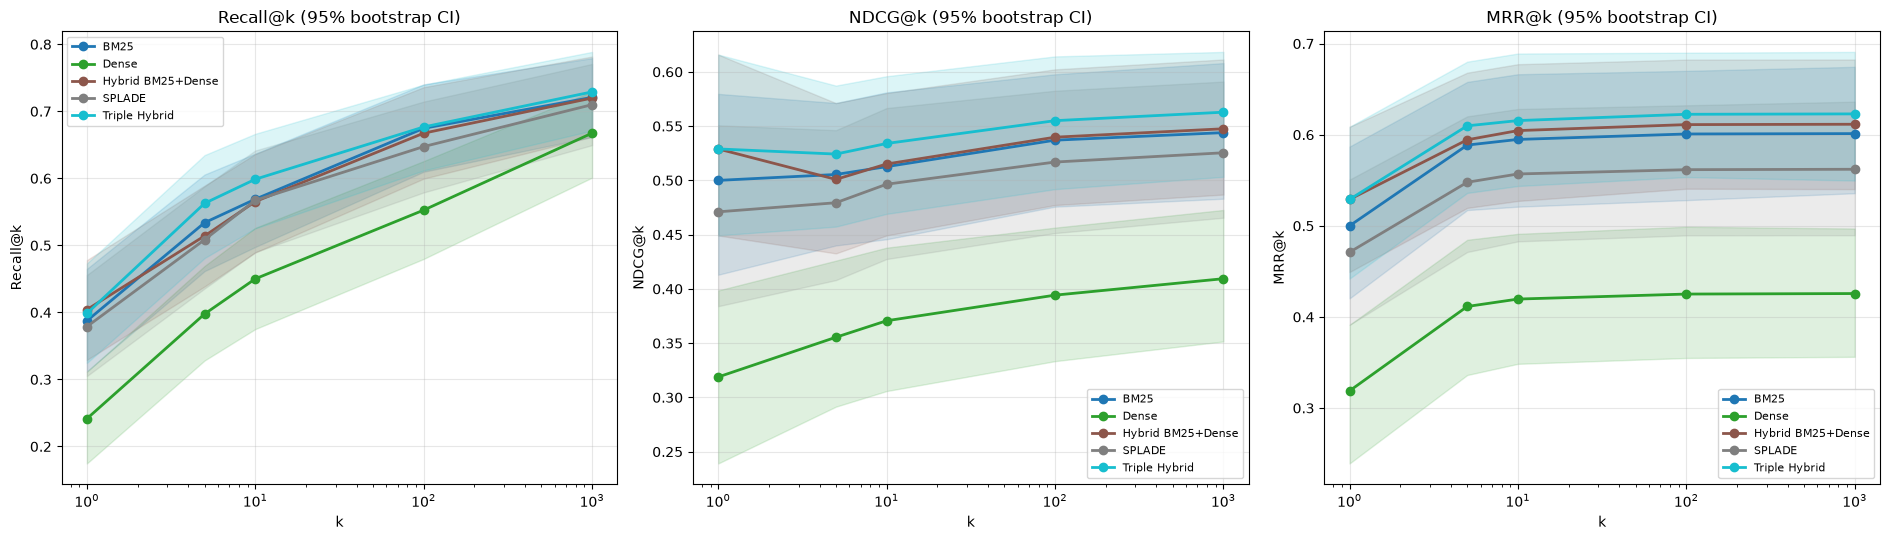

График сохранён: retrieval_analysis_plots/metrics_vs_k.png


In [ ]:
def plot_metrics_with_ci(per_query_by_method, k_values=K_VALUES, out_path=f"{OUT_DIR}/metrics_vs_k.png"):
    methods = list(per_query_by_method.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    for ax, metric in zip(axes, ["Recall", "NDCG", "MRR"]):
        for method, color in zip(methods, colors):
            means, ci_los, ci_his = [], [], []
            for k in k_values:
                vals = per_query_by_method[method][k][metric].to_numpy()
                boot_idx = np.random.randint(0, len(vals), size=(2000, len(vals)))
                boot_means = vals[boot_idx].mean(axis=1)
                lo, hi = np.percentile(boot_means, [2.5, 97.5])
                means.append(vals.mean())
                ci_los.append(lo)
                ci_his.append(hi)
            ax.plot(k_values, means, marker="o", label=method, color=color, linewidth=2)
            ax.fill_between(k_values, ci_los, ci_his, color=color, alpha=0.15)

        ax.set_xlabel("k")
        ax.set_ylabel(f"{metric}@k")
        ax.set_title(f"{metric}@k (95% bootstrap CI)")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_metrics_with_ci(per_query_by_method)

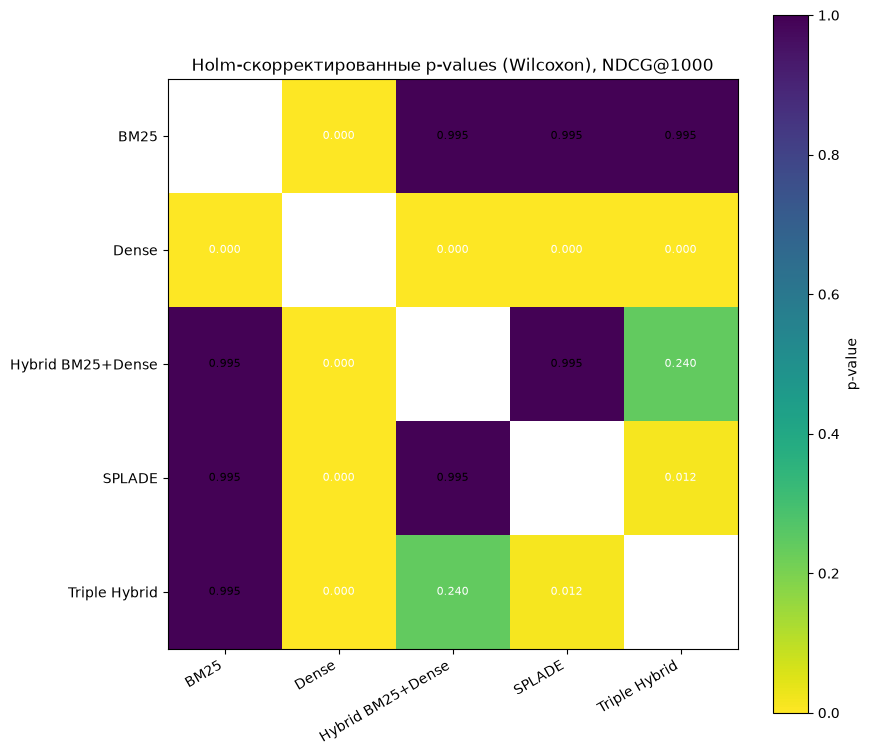

График сохранён: retrieval_analysis_plots/pvalue_heatmap_NDCG_at_k1000.png


In [ ]:
def plot_pvalue_heatmap(tests_df, k=10, metric="NDCG", out_path=None):
    if out_path is None:
        out_path = f"{OUT_DIR}/pvalue_heatmap_{metric}_at_k{k}.png"

    sub = tests_df[(tests_df["k"] == k) & (tests_df["metric"] == metric)]
    methods = sorted(set(sub["method_A"]) | set(sub["method_B"]))
    mat = pd.DataFrame(np.ones((len(methods), len(methods))), index=methods, columns=methods)
    for _, row in sub.iterrows():
        mat.loc[row["method_A"], row["method_B"]] = row["p_wilcoxon_holm"]
        mat.loc[row["method_B"], row["method_A"]] = row["p_wilcoxon_holm"]
    
    # Исправление: устанавливаем диагональ через iloc
    for i in range(len(methods)):
        mat.iloc[i, i] = np.nan

    fig, ax = plt.subplots(figsize=(1.4 * len(methods) + 2, 1.4 * len(methods) + 1))
    # mat.values может быть read-only, но мы используем mat.to_numpy() для imshow (это копия)
    im = ax.imshow(mat.to_numpy(dtype=float), cmap="viridis_r", vmin=0, vmax=1)
    ax.set_xticks(range(len(methods)))
    ax.set_yticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.set_yticklabels(methods)
    for i in range(len(methods)):
        for j in range(len(methods)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color="white" if val < 0.5 else "black", fontsize=8)
    ax.set_title(f"Holm-скорректированные p-values (Wilcoxon), {metric}@{k}")
    fig.colorbar(im, label="p-value")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_pvalue_heatmap(tests_df, k=1000, metric="NDCG")

## Метрики по типам вопросов

Средние по всем 138 запросам маскируют структуру провалов: часть типов вопросов (`intra_document_reasoning`, `completeness`, `conflicting_info`) требует не «более похожего чанка», а другой архитектуры (multi-hop, doc-level первый проход, recency/версионность), и ни ретривер, ни реранкер сами по себе это не чинят. Ниже — метрики отдельно по каждому `question_type`.

**Осторожно с размером групп.** Часть типов представлена очень малым числом вопросов (`conflicting_info`: 5, `miscellaneous`: 7, `intra_document_reasoning`/`constrained`: 10) — средние по ним шумные, а полноценные Wilcoxon-тесты внутри такой группы почти не имеют статистической мощности. Ниже приводится описательная разбивка (с `n_queries` в каждой ячейке), а не отдельные p-values по типам — делать далекоидущие выводы про конкретную группу из 5 вопросов не стоит, но сама картина (в каких типах разрыв между методами и в каких типах все методы одинаково слабы) уже информативна.

In [ ]:
# ==== Загрузка типов вопросов ====

def load_question_types():
    df_q = pd.read_parquet(QUESTIONS_PARQUET)
    candidates = ["question_type", "qtype", "type", "category"]
    col = next((c for c in candidates if c in df_q.columns), None)
    if col is None:
        raise KeyError(
            f"Не найдена колонка с типом вопроса. "
            f"Доступные колонки: {list(df_q.columns)}"
        )
    print(f"Колонка типа вопроса: '{col}'")
    qtype_by_qid = dict(zip(df_q["question_id"], df_q[col]))
    print("\nКоличество вопросов по типам:")
    print(df_q[col].value_counts())
    return qtype_by_qid

qtype_by_qid = load_question_types()

In [ ]:
# ==== Метрики по (метод, k, тип вопроса) ====

def metrics_by_qtype(per_query_by_method, qtype_by_qid, k_values=K_VALUES,
                      metrics=("Recall", "NDCG", "MRR")):
    rows = []
    for method, per_k in per_query_by_method.items():
        for k in k_values:
            df = per_k[k].copy()
            df["question_type"] = df.index.map(qtype_by_qid)
            for qtype, group in df.groupby("question_type", dropna=False):
                row = {"Method": method, "k": k, "question_type": qtype,
                       "n_queries": len(group)}
                for m in metrics:
                    row[m] = group[m].mean()
                rows.append(row)
    return pd.DataFrame(rows)

qtype_df = metrics_by_qtype(per_query_by_method, qtype_by_qid)

print("Число вопросов на (тип, метод) при k=10 — должно быть одинаковым по методам,\n"
      "если различается — где-то метод не покрывает часть qid (проверьте пересечение):")
display(
    qtype_df[qtype_df["k"] == 10]
    .pivot(index="question_type", columns="Method", values="n_queries")
)

In [ ]:
# ==== Таблицы метрик по типам вопросов ====

K_QTYPE_SHOW = 10  # основная точка отсечения для просмотра

for metric in ["Recall", "NDCG", "MRR"]:
    print(f"\n{metric}@{K_QTYPE_SHOW} по типам вопросов:")
    pivot = (
        qtype_df[qtype_df["k"] == K_QTYPE_SHOW]
        .pivot(index="question_type", columns="Method", values=metric)
    )
    # сортируем строки по среднему качеству, чтобы сразу видеть худшие типы наверху
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    display(pivot.round(3))

print(f"\nRecall@1000 по типам вопросов (потолок по recall для каждого типа):")
pivot_r1000 = (
    qtype_df[qtype_df["k"] == 1000]
    .pivot(index="question_type", columns="Method", values="Recall")
)
pivot_r1000 = pivot_r1000.loc[pivot_r1000.mean(axis=1).sort_values().index]
display(pivot_r1000.round(3))

In [ ]:
# ==== Heatmap NDCG@10 по (метод x тип вопроса) ====

def plot_qtype_heatmap(qtype_df, k=10, metric="NDCG", out_path=None):
    if out_path is None:
        out_path = f"{OUT_DIR}/qtype_heatmap_{metric}_at_k{k}.png"

    sub = qtype_df[qtype_df["k"] == k]
    pivot = sub.pivot(index="question_type", columns="Method", values=metric)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(1.6 * len(pivot.columns) + 2, 0.6 * len(pivot.index) + 2))
    im = ax.imshow(pivot.to_numpy(dtype=float), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        color="white" if val < 0.5 else "black", fontsize=8)
    ax.set_title(f"{metric}@{k} по типам вопросов")
    fig.colorbar(im, label=metric)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_qtype_heatmap(qtype_df, k=10, metric="NDCG")
plot_qtype_heatmap(qtype_df, k=1000, metric="Recall")

**Как читать эти таблицы.** Строки отсортированы по среднему качеству (снизу — типы, где все методы работают лучше всего; сверху — проблемные). Если у `intra_document_reasoning` / `completeness` / `conflicting_info` низкий Recall@1000 **у всех методов одновременно** (а не только у какого-то одного) — это подтверждает гипотезу, что проблема не в выборе ретривера/реранкера, а в архитектуре (нужны multi-hop / doc-level первый проход / учёт версионности документов). Если же разброс между методами внутри одного типа большой — есть шанс закрыть это выбором метода, а не переделкой пайплайна.